---

# <span style="color:#1F4E79;">Fundamentals of Underwater Acoustics and Optical Systems</span>
### <span style="color:#2E86AB;">Lecture 4 · Phased Array Sonars</span>

---

## <span style="color:#1F4E79;">Table of Contents</span>
- [Part 1: Simulating Signals](#Part-1:-Simulating-Signals)
- [Part 2: Reconstructing the Position](#Part-2:-Reconstructing-the-Position)
- [Part 3: Simulating the Signal - Changed Beacon Position](#Part-3:-Simulating-the-Signal---Changed-Beacon-Position)

---

In [ ]:
# Import necessary libraries
import sympy as sp
import math
import numpy as np

# Part 1: Simulating Signals
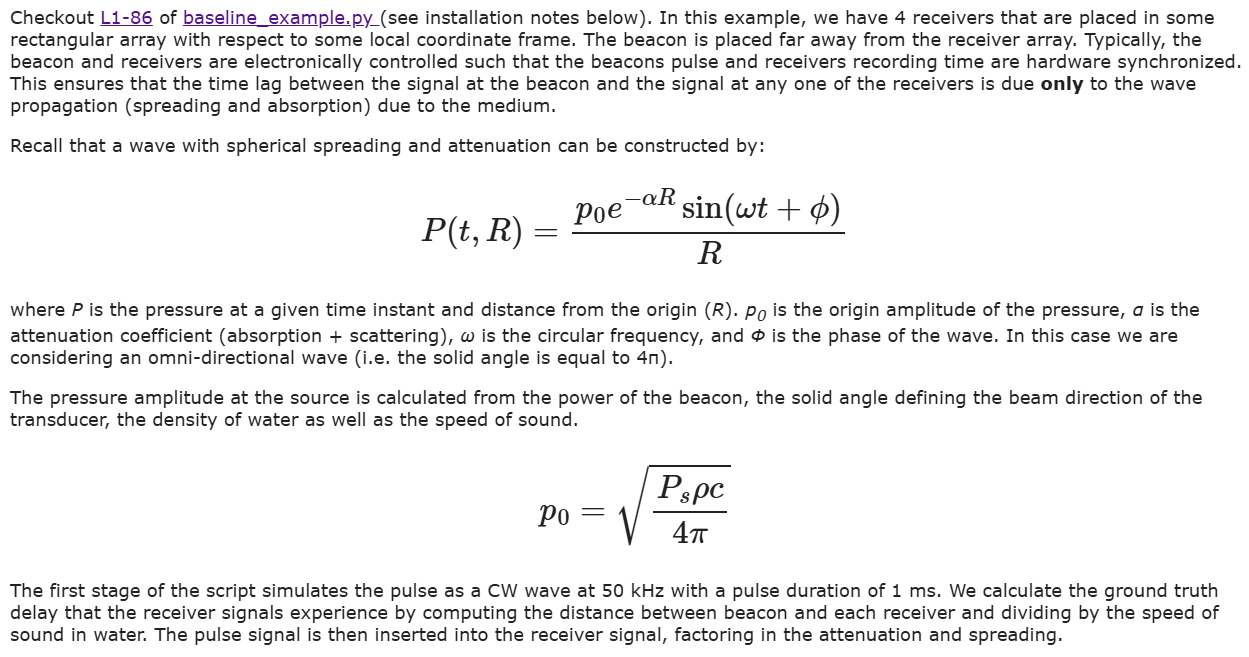

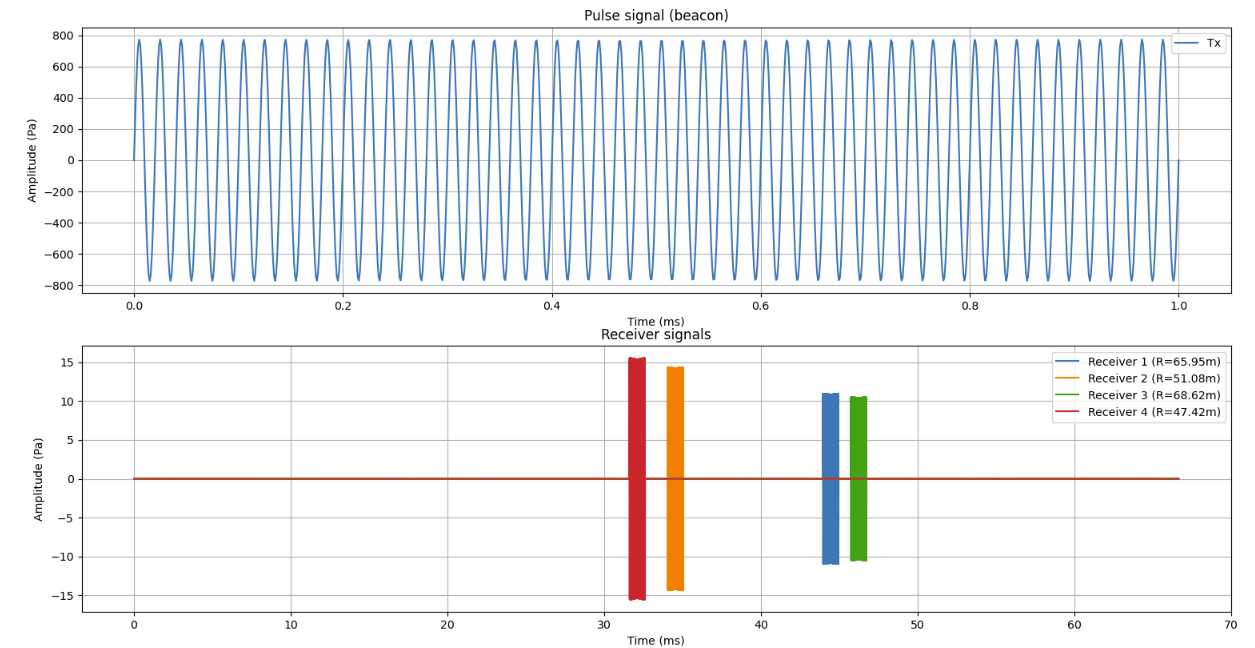
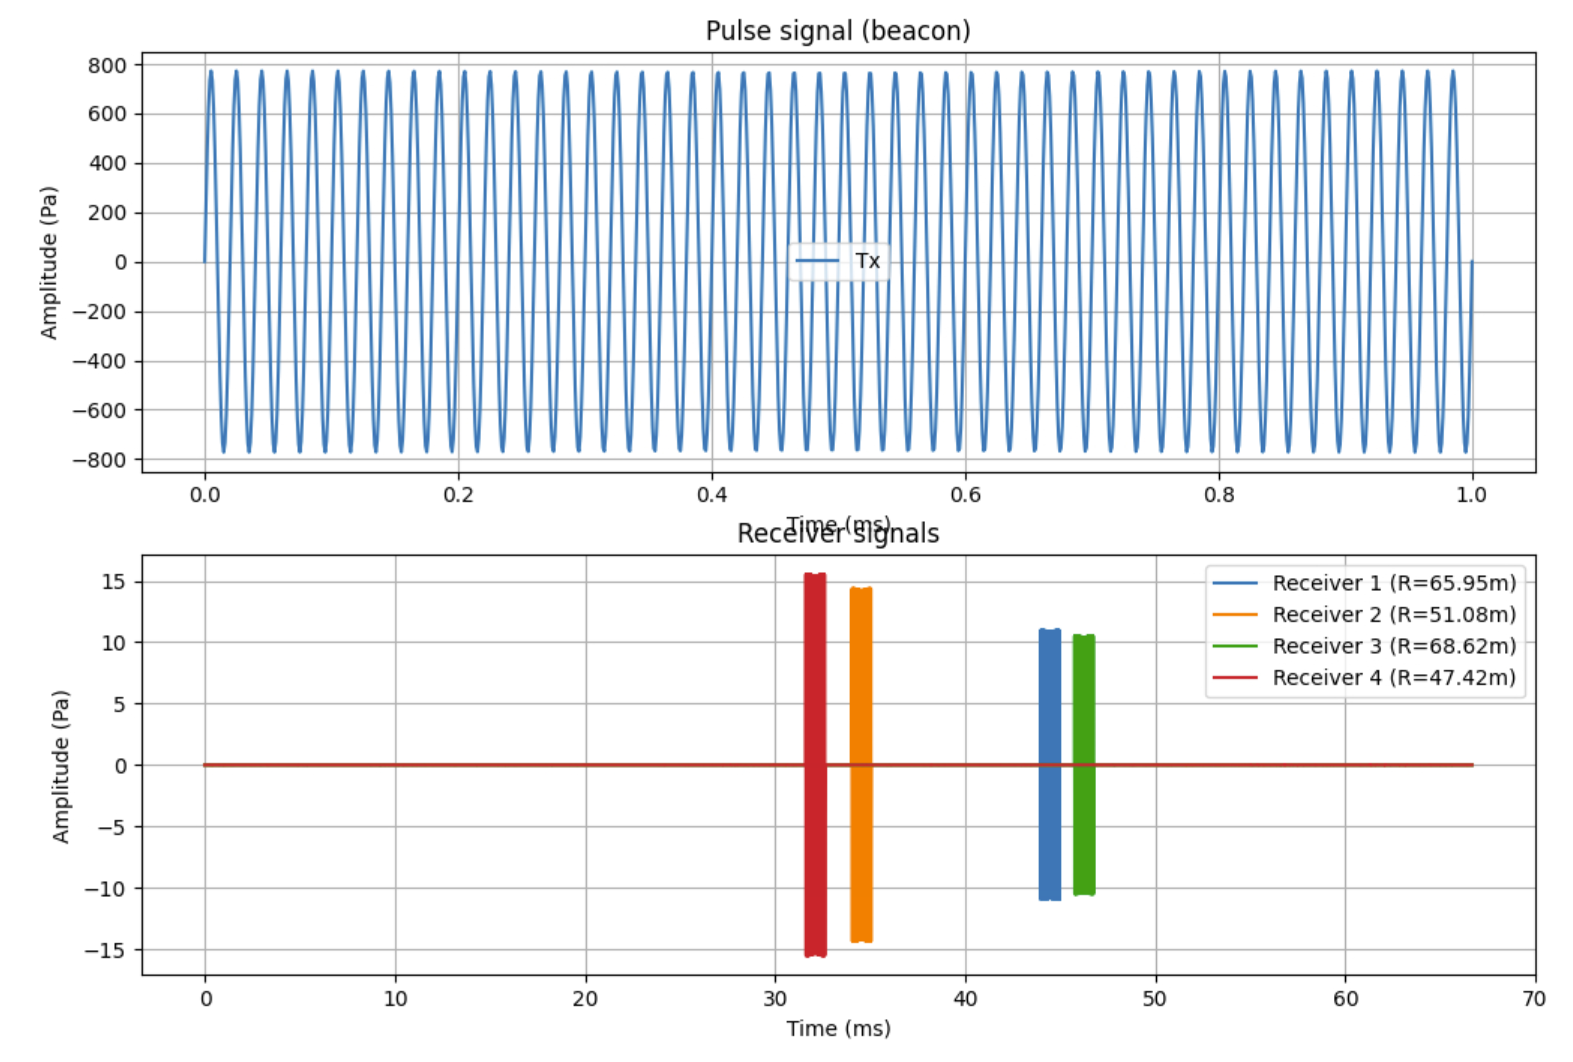
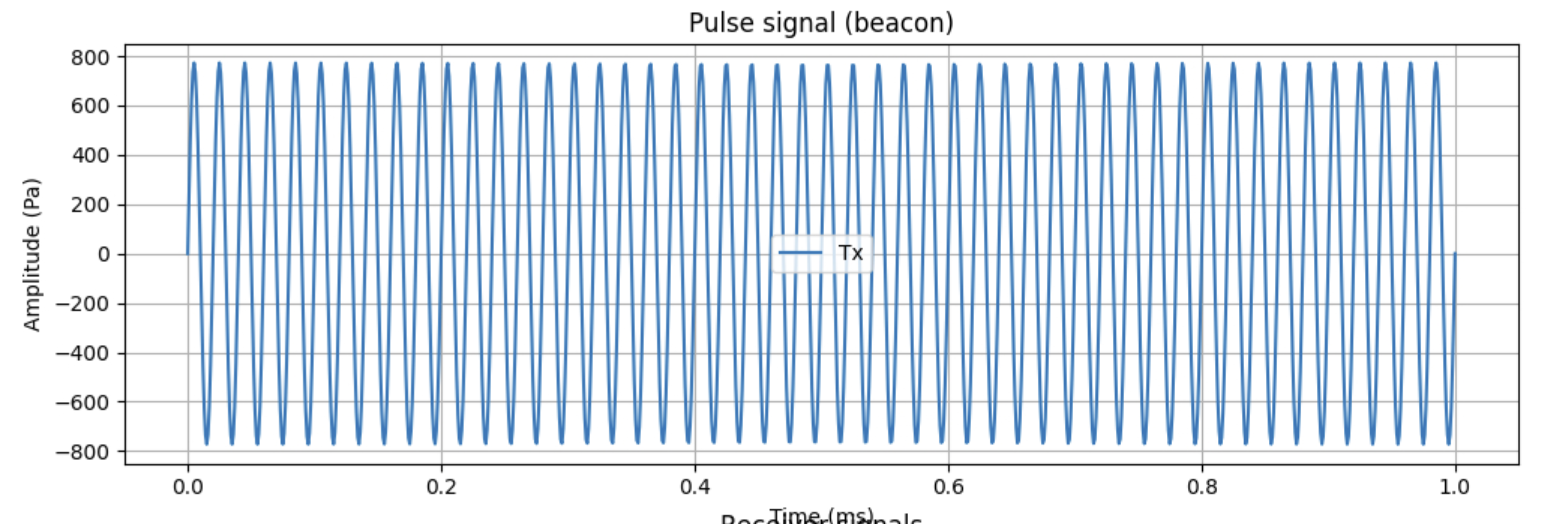

### Top: **`Pulse signal (beacon)`**
- This is the transmitted sinusoidal burst (`Tx`) over about **1 ms**.
- Peak amplitude is around **±780 Pa**.

### Bottom: **`Receiver signals`**
- Each colored trace is the same pulse, but:
  1. **Shifted in time** (propagation delay),
  2. **Reduced in amplitude** (spreading loss).

From your legend:
- R4 = 47.42 m → arrives first (~31.6 ms)
- R2 = 51.08 m → next (~34.1 ms)
- R1 = 65.95 m → later (~44.0 ms)
- R3 = 68.62 m → last (~45.7 ms)

So the plot is showing exactly what you expect: **closer receivers get earlier and stronger signals**.

---

## Why the pulses look like “vertical bars”
You are plotting a **very short, high-frequency pulse** on a long time axis (0–70 ms), so the oscillations visually collapse into thick vertical bands.  
Nothing is wrong.

If you zoom x-axis around each arrival window (e.g., 30–36 ms and 43–47 ms), you’ll see normal sine waves.

---

## For your spreading-model question on this plot
- Changing spherical → cylindrical/planar will mainly change **amplitude drop** between receivers.
- **Arrival times** stay the same (if sound speed is unchanged).
- So TDOA localization is mostly unchanged; RSS/amplitude-based range estimates will change.

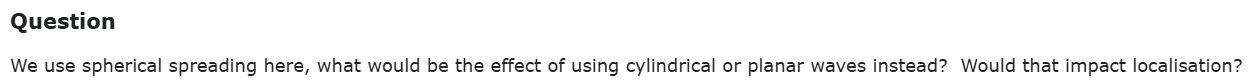

Using **cylindrical or planar** instead of **spherical** mainly changes how fast signal strength drops with distance:

- **Spherical:** strongest decay (energy spreads in 3D).
- **Cylindrical:** less decay.
- **Planar:** almost no geometric decay.

**Does it impact localisation?**
- **TDOA (Time Difference Of Arrival)/arrival-time localisation:** usually little direct change (times mostly same if sound speed same), but SNR (Signal-to-noise ratio) changes can make timing picks better/worse.
- **Amplitude/RSS-based localisation:** yes, it can change results a lot, because the range-vs-level model changes.

Simple takeaway: **it mostly affects amplitudes; localisation impact is small for pure timing methods, larger for level-based methods.**

For 3D cases, spherical spreading is most realistic. However for 2D problems at relatively short distances the error between using planar or cylindrical would be small. Also, changing the spreading model mainly changes amplitudes (SNR and relative levels), and that can indirectly affect localization. It won’t change the true arrival times you’re simulating, but it changes how easy it is to detect/estimate those arrival times and (if you use amplitudes) how you weight different receivers.

# Part 2: Reconstructing the Position

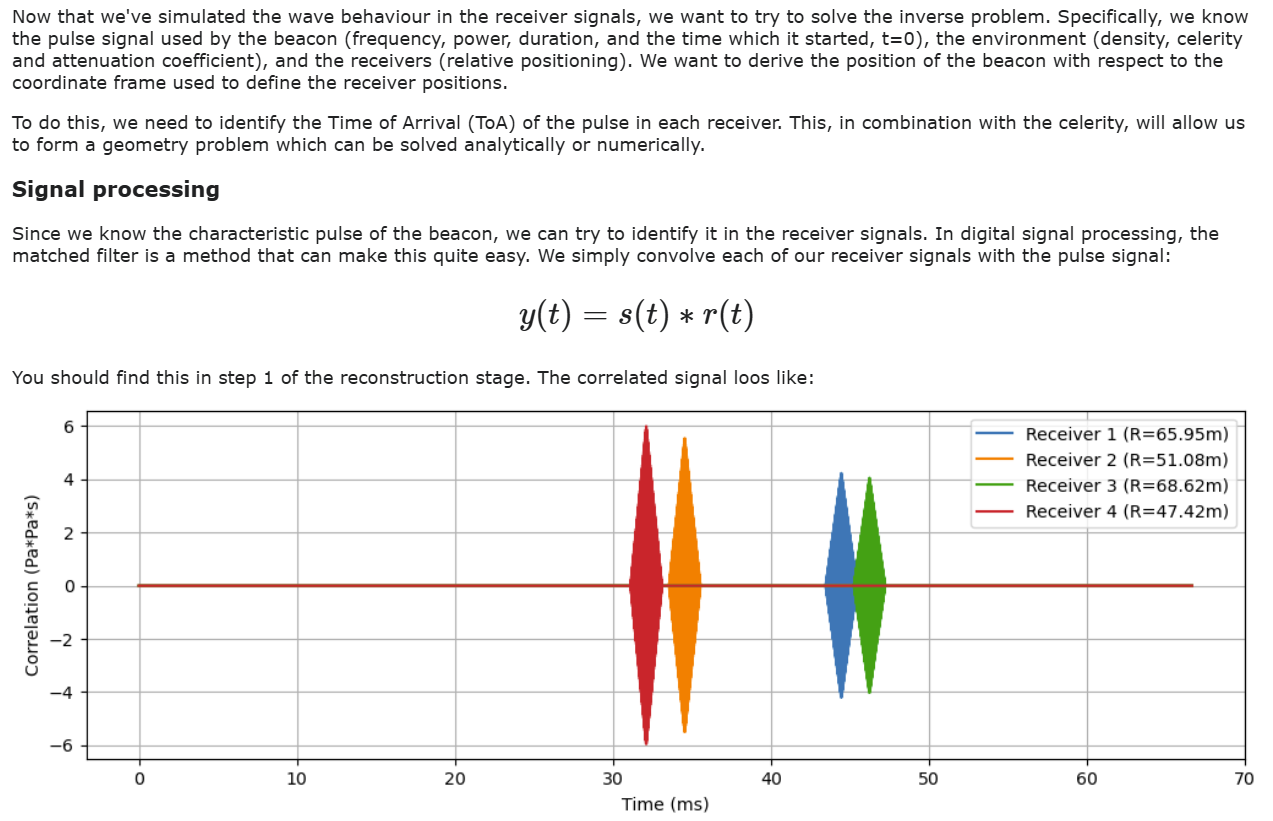
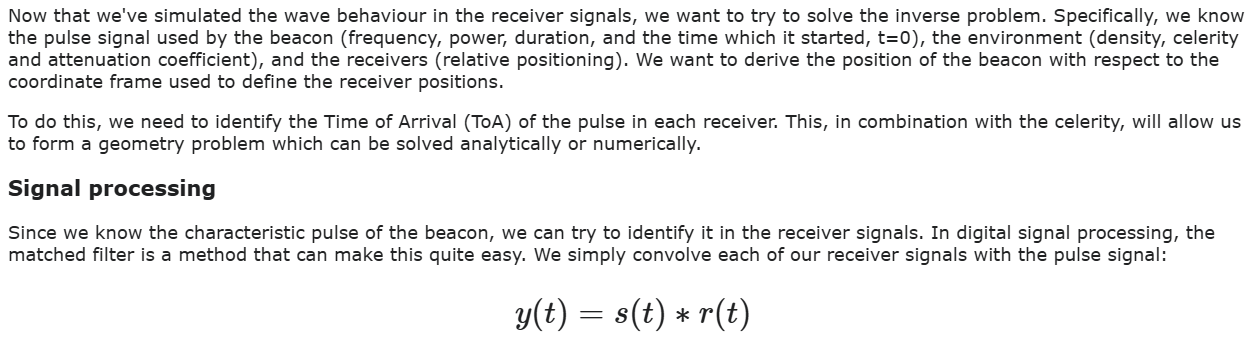

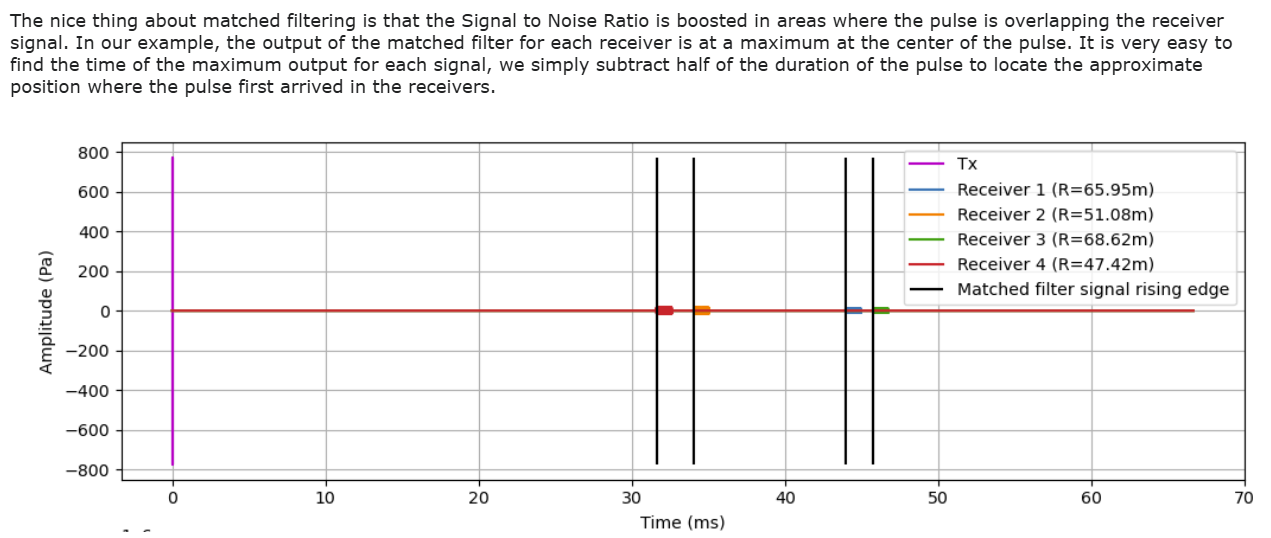
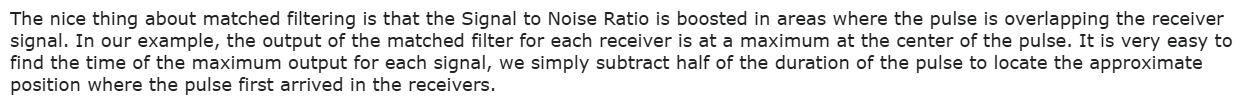

## 1) Top plot (signals + black timing lines)

- **Magenta `Tx` at ~0 ms**: transmit pulse reference time.
- Colored receiver traces are delayed arrivals (same as before), but compressed on a long time axis so they look like short blocks.
- **Black vertical lines** = detected **arrival instants** from your matched-filter “rising edge” logic.
  - Around **31–35 ms**: nearer receivers (R4, R2)
  - Around **44–46 ms**: farther receivers (R1, R3)

So this panel says: *“Here are the signals, and here are the times the detector picked.”*

---

## 2) Bottom plot (matched-filter / correlation outputs)

- This is the correlation of each receiver signal with the known transmitted pulse.
- Where correlation is near zero: no pulse present.
- Around each arrival time, you get a strong oscillatory burst/peak:
  - Bigger peak = stronger received signal (closer source, less spreading loss)
  - Peak time = estimated arrival time

That’s why red/orange peaks are earlier and larger than blue/green.

---

## Key takeaway

These two together show:
1. **Detection times are correct** (black lines align with correlation peaks), and  
2. **Order is physically consistent** with range: closer receivers arrive first and stronger.

If you want, I can help you add a tiny code cell that marks the exact peak sample/time numerically in a clean table (`receiver`, `t_arrival_ms`, `R_est = c*t`).

---

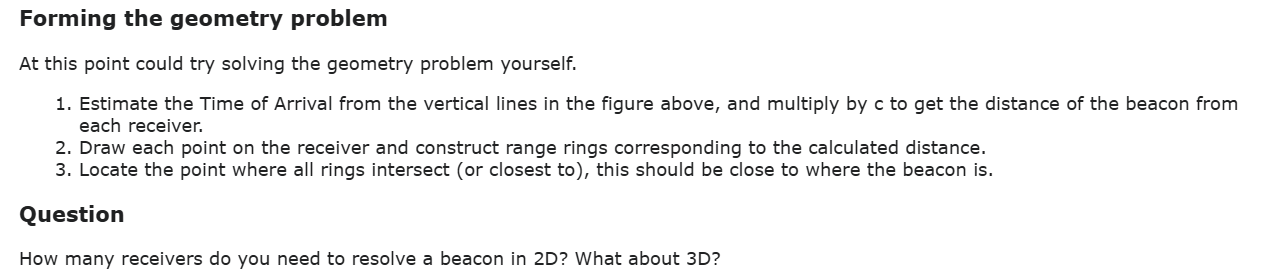

Three for 2D, since there is a point of symmetry, Four for 3D, since there is a plane of symmetry.

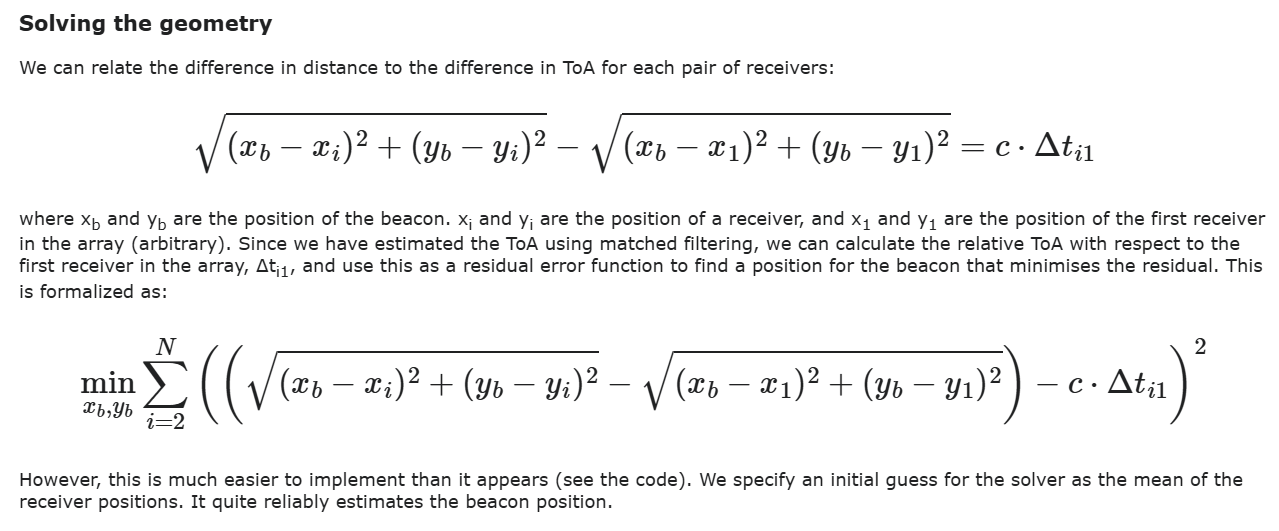

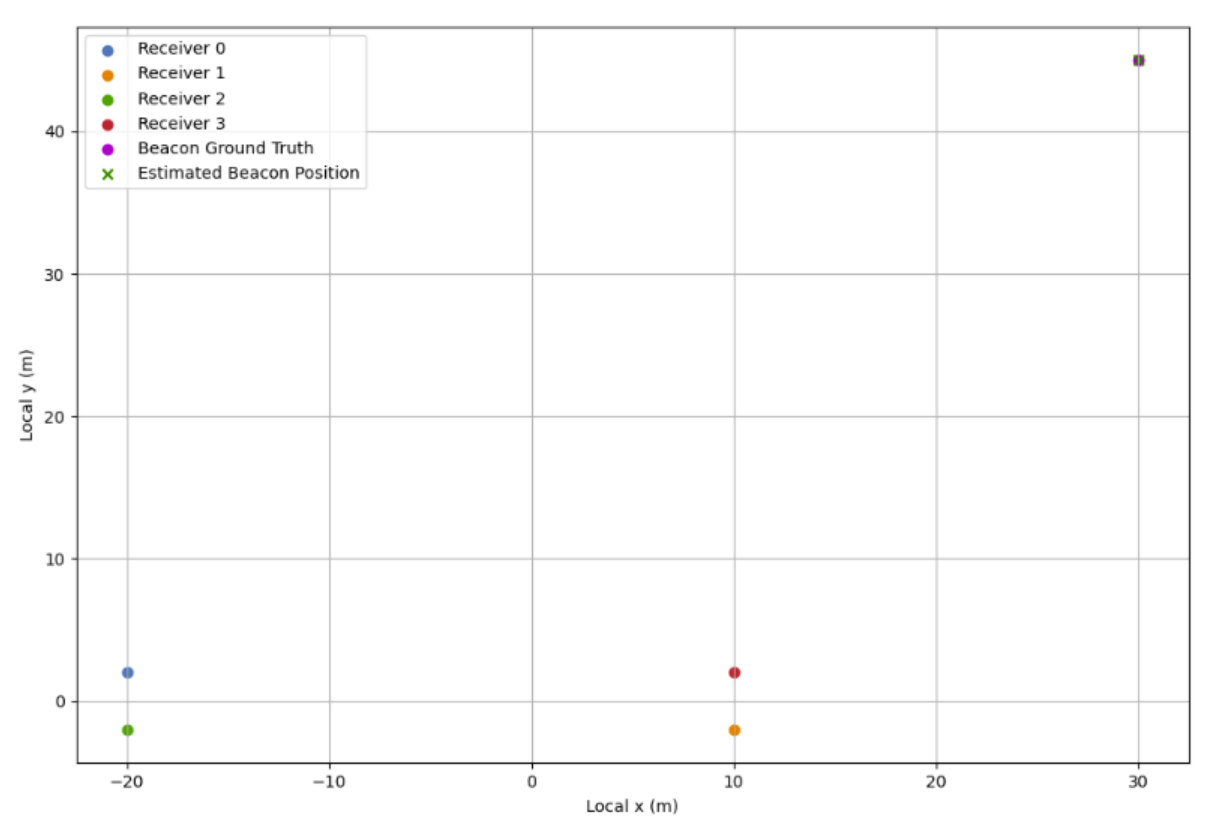

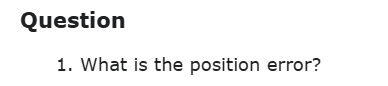

From this plot, the estimated beacon (x) is essentially on top of the ground-truth point, so the position error is approximately 0 m (visually negligible).

# Part 3: Simulating the Signal - Changed Beacon Position

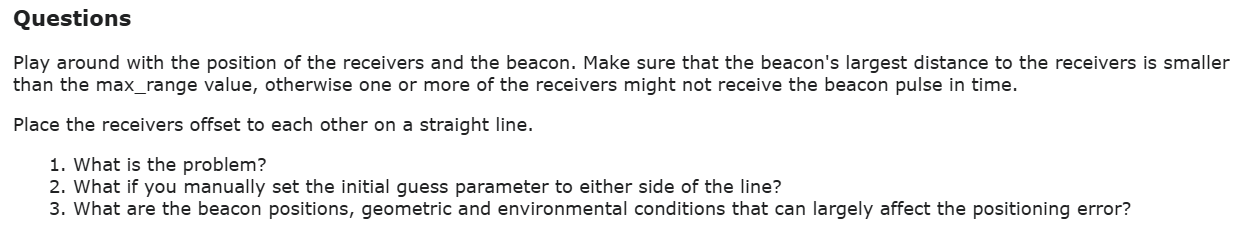

**1) Receivers on one straight line: what is the problem?**
- You get a geometry degeneracy in 2D TDOA.
- For many timing sets, there are two symmetric beacon solutions (one on each side of the receiver line).
- Vertical/perpendicular position becomes weakly observable, so small timing noise creates large position error.
- In short: localization becomes ambiguous and unstable.

**2) If initial guess is set to either side of the line**
- The least-squares solver usually converges to the solution on that same side.
- So you can get two different valid-looking estimates from the same data (mirror solutions).
- This is why your estimate may “jump” depending on initial guess when array geometry is collinear.

**3) What conditions strongly increase positioning error?**
- Poor geometry: collinear receivers, small aperture, beacon far outside array footprint.
- Beacon location: far range, near line extensions, or where TDOA differences are very small.
- Timing limits: low sample rate, wide correlation peaks, threshold-based TOA instead of peak/interpolated TOA.
- Noise/multipath: low SNR, reflections/reverberation, interference.
- Environmental mismatch: wrong sound speed profile, temperature/salinity/depth gradients, unmodeled currents.
- Model mismatch: simplified propagation assumptions vs real channel behavior.

**Practical takeaway**
- Use non-collinear receiver geometry (triangle/box), larger aperture, high-SNR matched-filter peak timing with sub-sample interpolation, and realistic sound-speed modeling.  
Want me to draft a short markdown “Answers” cell you can paste into your notebook?

### a) Changed Beacon's Location (Further from the receivers)
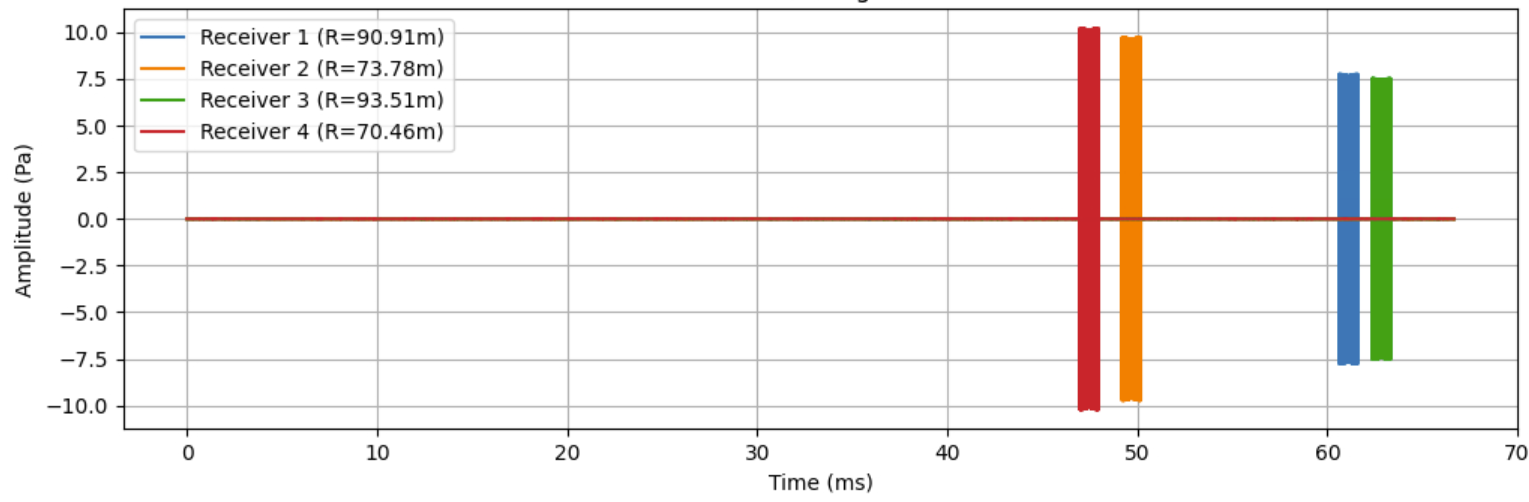
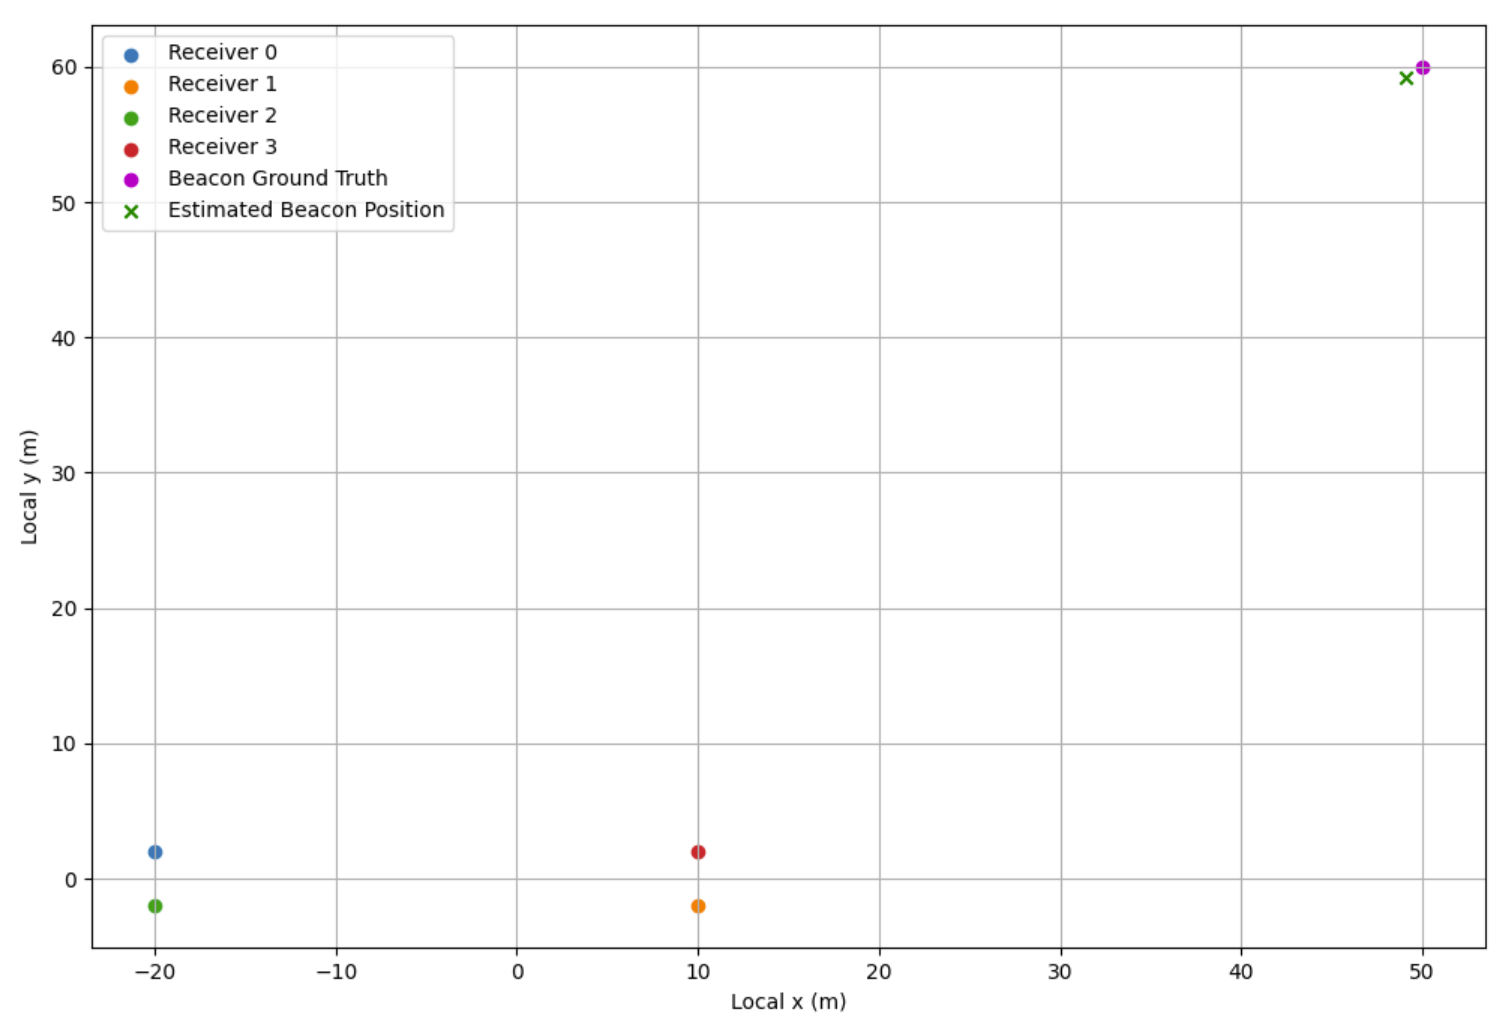

This is normal, and your new plot actually shows a **small, expected estimation error**.

Main reasons it appears after moving the beacon:

- **Farther source = weaker signal** at all receivers, so TOA picks are a bit less precise.
- Your detector likely uses **sample-based timing** (discrete samples), so arrival times are quantized to \(\Delta t = 1/f_s\).
- If you use **rising-edge threshold timing**, amplitude differences can shift the detected time slightly at each receiver.
- The beacon is now **outside the receiver cluster**, which worsens geometry (higher GDOP), so tiny timing errors map to bigger position error.

So the mismatch does **not** necessarily mean your method is wrong—just that uncertainty is now visible.

Quick ways to reduce it:
- use matched-filter **peak** time (not first threshold crossing),
- increase sampling rate,
- add sub-sample interpolation (parabolic fit around correlation peak),
- optionally add one more receiver / widen array aperture.



### b) Changed Beacon's Location (Closer to the receivers)

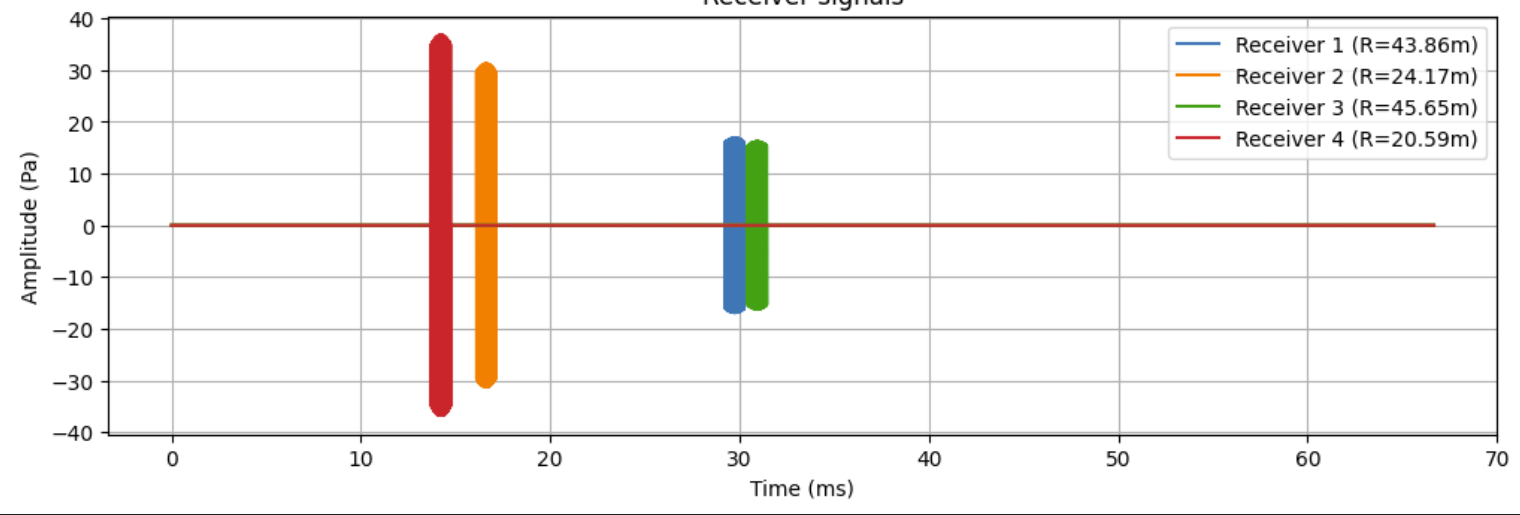
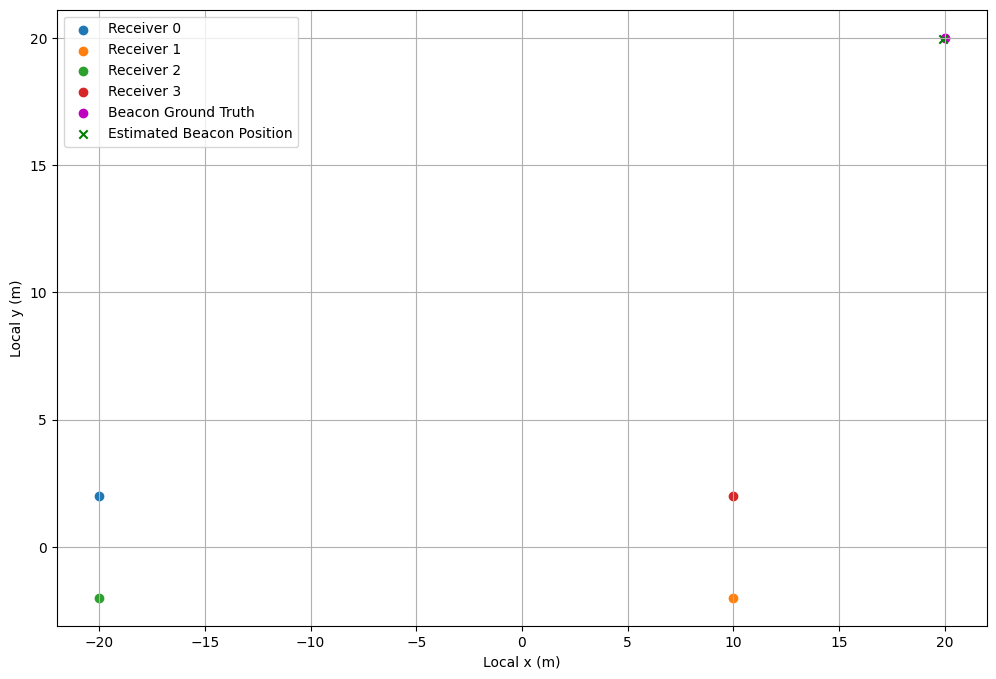

### c) Changed Location of the Beacons (Placed in Line)

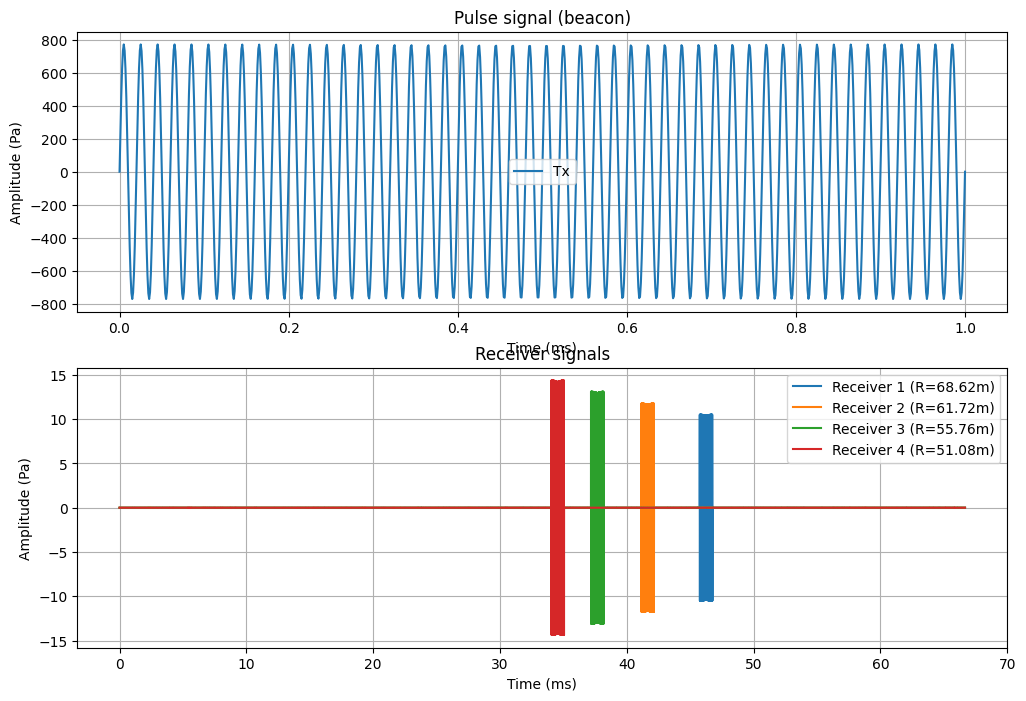
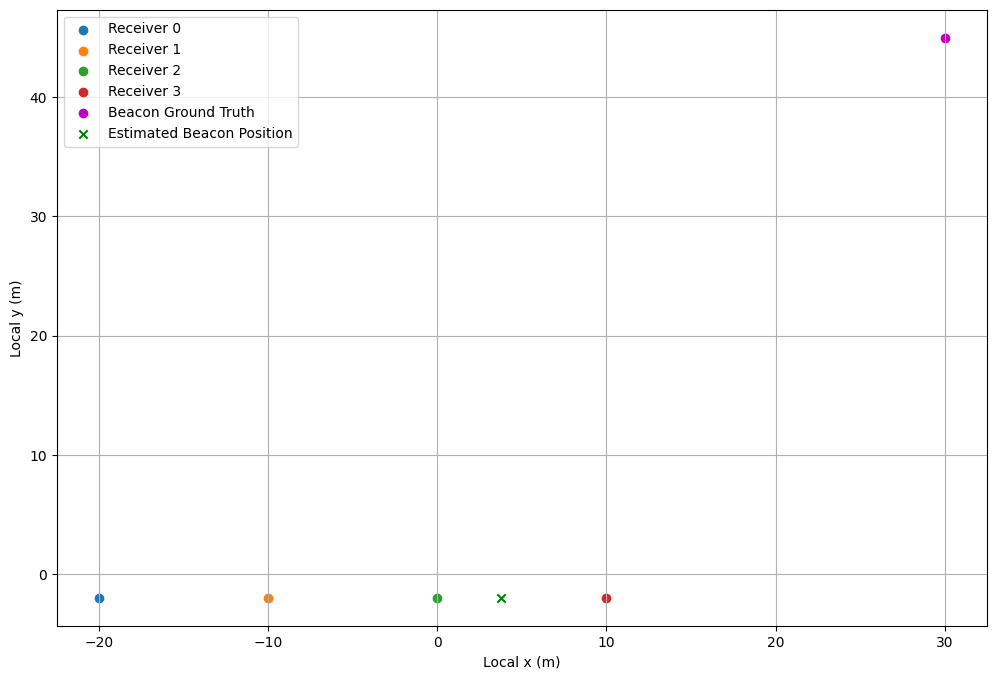

## Code 

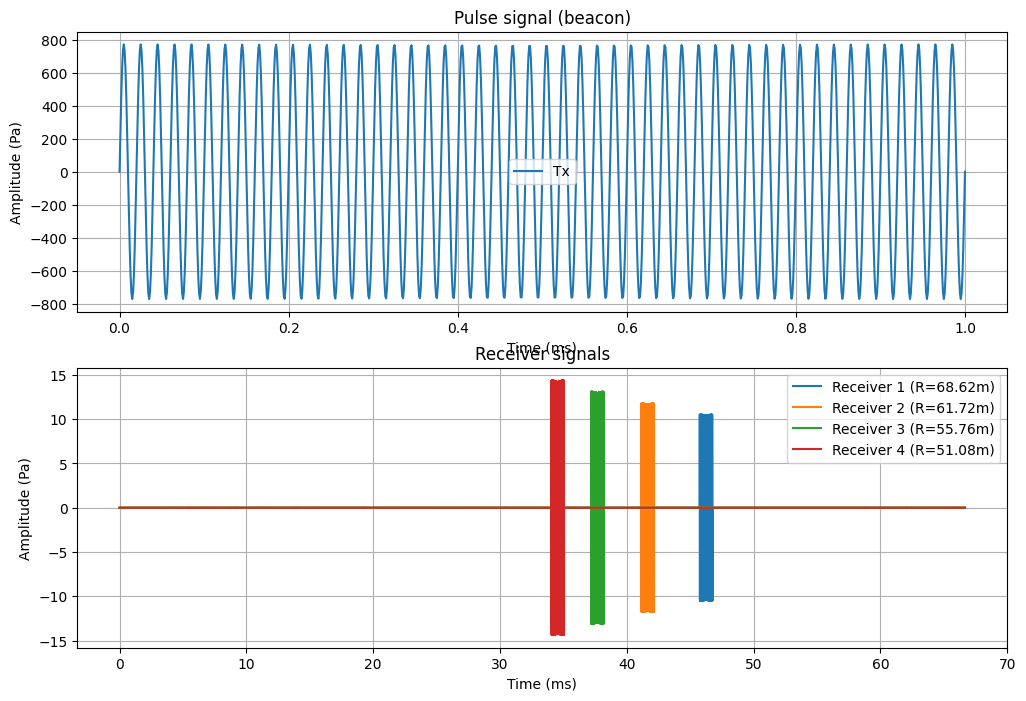

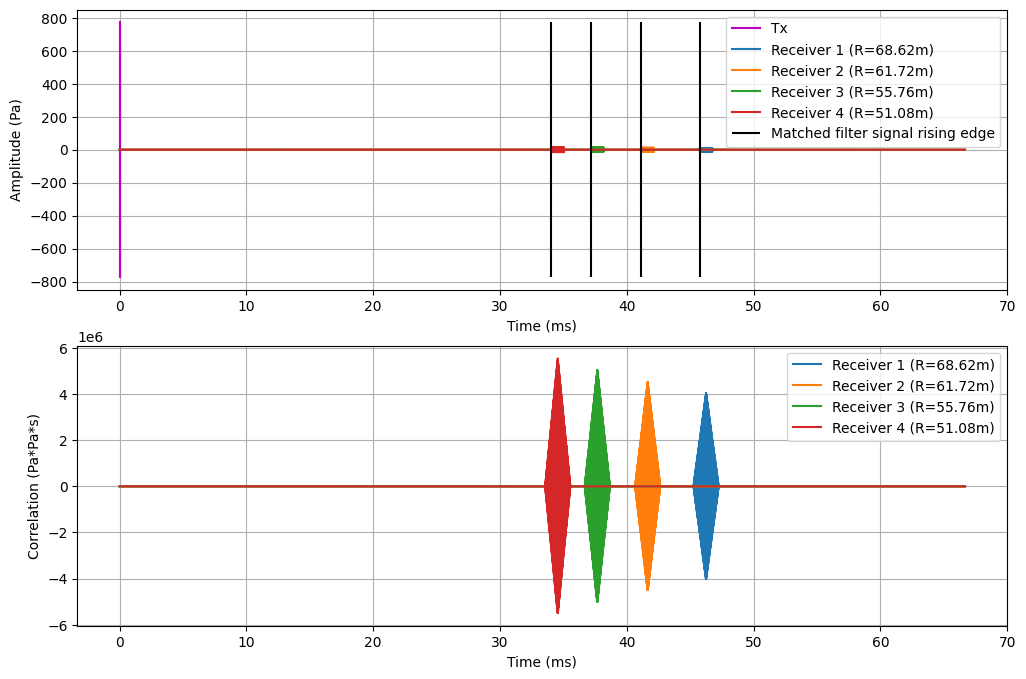

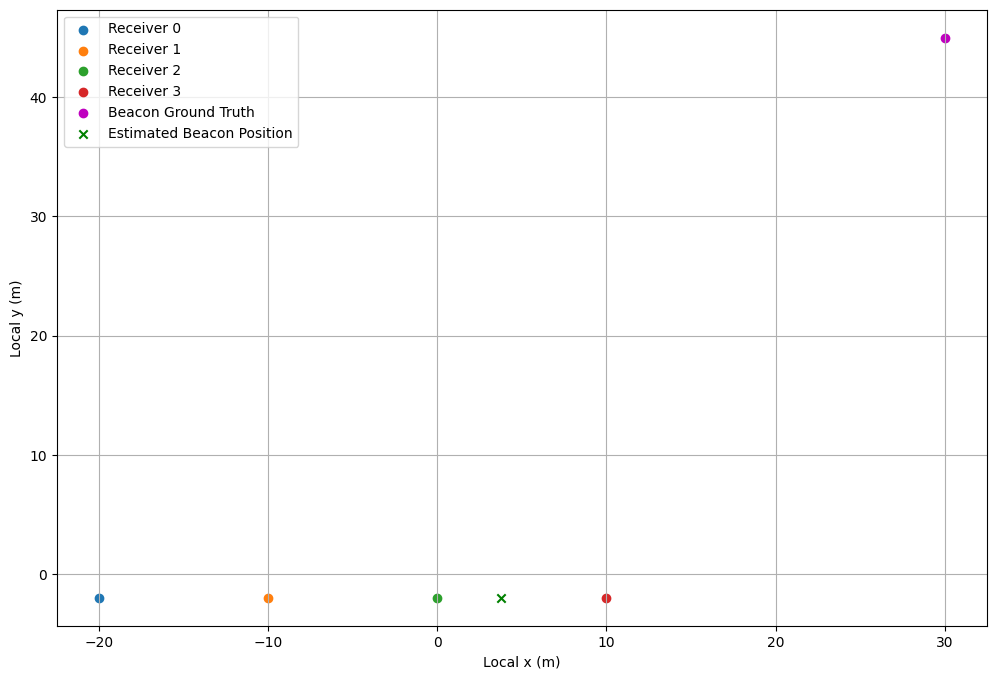

In [5]:
import numpy as np
from matplotlib import pyplot as plt

#######################################################################################################################
# Problem generation stage
# environment
rho = 1000.  # density of water
c = 1500  # speed of sound in fresh water
alpha = 1e-3  # absorption coefficient

# beacon
beacon_position = np.array(((30, 45)), float)  # beacon position with respect to local coordinate frame
frequency = 50_000  # frequency of pulse in Hz
P_s = 5.0  # Beacon transmit power in watts
pulse_duration = 1e-3  # duration of pulse in s
self_noise = 1e-3  # noise for beacon and receivers

# receivers
receiver_position = np.array(((-20, 2), (10, -2), (-20, -2), (10, 2)), float)  # location of receivers with respect to local coordinate frame
receiver_position = np.array(((-20, -2), (-10, -2), (0, -2), (10, -2)), float)
max_range = 100  # maximum range to listen for
listen_time = max_range / c  # number of seconds of listening time
sample_rate = 1_000_000  # sampling rate of receivers

# Simulation
# calculate some variables based on given information on environment, beacon and receivers
T = 1.0 / frequency  # wave period
w = 2.0 * np.pi * frequency  # circular wave frequency (rad/s)
k = w / c  # wave number
listen_samples = int(np.ceil(listen_time * sample_rate))
t = np.linspace(0, listen_time, listen_samples)  # discrete sampling time vector across listening time
R = np.linalg.norm(receiver_position - beacon_position, axis=1)  # the ground truth distance of the beacon from the receivers

# Generate the pulse at the beacon
pulse_time = np.linspace(0, pulse_duration, int(pulse_duration * sample_rate))  # pulse time
p0 = np.sqrt((P_s * rho * c) / (4 * np.pi))  # Pressure amplitude at beacon
pulse_signal = p0 * np.sin(w * pulse_time)  # generate the pressure wave at the beacon
pulse_signal += np.random.normal(loc=0.0, scale=self_noise, size=int(pulse_duration * sample_rate))  # self-noise

# Generate received signals with correct delays
t_delays = R / c  # expected time delay for when pulse should reach each receiver
received_signals = np.zeros((len(t), len(receiver_position)))  # storage for received signals

# Simulate the signal at each receiver
for i, t_delay in enumerate(t_delays):
    # Compute time indices where the pulse should start
    start_idx = int(t_delay * sample_rate)
    end_idx = start_idx + len(pulse_signal)
    if end_idx < len(t):
        received_signals[start_idx:end_idx, i] = pulse_signal / R[i] * np.exp(-alpha * R[i])  # Apply spherical attenuation (1/R) and absorption
received_signals = received_signals + np.random.normal(loc=0.0, scale=self_noise, size=(len(received_signals), 4))

# Plot pulse and received signals
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].plot(pulse_time * 1000, pulse_signal, label=f"Tx")
for i in range(len(receiver_position)):
    ax[1].plot(t * 1000, received_signals[:, i], label=f"Receiver {i+1} (R={R[i]:.2f}m)")

ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Amplitude (Pa)")
ax[0].set_title("Pulse signal (beacon)")
ax[0].legend()
ax[0].grid()
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Amplitude (Pa)")
ax[1].set_title("Receiver signals")
ax[1].legend()
ax[1].grid()

#######################################################################################################################
# Reconstruction stage
# We know:
#   1. Position of receivers
#   2. The pulse signal of the beacon
#   3. The environment (density, celerity)

from scipy.signal import correlate
from scipy.optimize import least_squares

# Plot pulse and received signals in a new figure
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].plot(pulse_time, pulse_signal, label=f"Tx", color="m")
for i in range(len(receiver_position)):
    ax[0].plot(t * 1000, received_signals[:, i], label=f"Receiver {i+1} (R={R[i]:.2f}m)")

# Step 1: filter the signal to find where the pulse is arriving on each receiver
# Matched filtering, since we know what the pulse looks like, lets convolve it over the receiver signals
filtered_signals = np.zeros_like(received_signals)
for i in range(received_signals.shape[1]):
    filtered_signals[:, i] = correlate(received_signals[:, i], pulse_signal, mode='same')
    ax[1].plot(t * 1000, filtered_signals[:, i], label=f"Receiver {i + 1} (R={R[i]:.2f}m)")

# The convolution produces a correlation signal, the maximum for each receiver's correlation signal is likely to be the center of the pulse.
argmax_signal = np.argmax(filtered_signals, axis=0)
# Subtract half of the pulse duration to locate the approximate position of the rising edge of the pulse.
t_rising = t[argmax_signal] - 0.5 * pulse_duration
ax[0].vlines(t_rising * 1000, ymin=-p0, ymax=p0, label="Matched filter signal rising edge", color='k')

ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Amplitude (Pa)")
ax[0].legend()
ax[0].grid()
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Correlation (Pa*Pa*s)")
ax[1].legend()
ax[1].grid()

# Step 2: Compute Time Difference of Arrival
R_rising = t_rising * c  # Compute the distance from beacon to each receiver as estimated by detected rising time
tdoa = t_rising - t_rising[0]  # Use first receiver as reference

# Step 3: Find the beacon position using least squares regression
def residuals(x):
    """ Function to minimize for least squares """
    x_s, y_s = x  # Estimated beacon position
    R_s = np.linalg.norm(receiver_position - np.array([x_s, y_s]), axis=1)
    estimated_tdoa = (R_s - R_s[0]) / c  # Expected TDOA
    return estimated_tdoa - tdoa  # Difference from measured TDOA

# Initial guess
initial_guess = np.mean(receiver_position, axis=0)
# Solver
result = least_squares(residuals, initial_guess, max_nfev=2000)
# Estimated beacon position relative to coordinate frame
estimated_relative_position = result.x

# Plot the results
fig, ax = plt.subplots(figsize=(12, 8))
for i, r in enumerate(receiver_position):
    ax.scatter(r[0], r[1], label=f"Receiver {i}")
ax.scatter(beacon_position[0], beacon_position[1], label="Beacon Ground Truth", color="m")
ax.scatter(estimated_relative_position[0], estimated_relative_position[1], label="Estimated Beacon Position", color="g", marker="x")
ax.set_xlabel("Local x (m)")
ax.set_ylabel("Local y (m)")
ax.legend(loc="best")
ax.grid()
plt.show()

#######################################################################################################################